# Planning the next study from the last one
**Learning with Machines workshop, October 5, 2026**

The Koch Institute's preclinical imaging core ran a **protocol-development study**: lung tumors from
a luciferase-reporter cell line delivered by ultrasound-guided intratracheal injection (USGI) in
**13 mice**, imaged weekly from **week 6 to week 14** on **microCT**, **MRI** and **IVIS**. The point
was to compare how well each modality measures lung tumors, so the image analyst focused on the
mice where there was tumor to measure.

Everything about the study sits in a knowledge graph: the mice, every scan, the analysis results,
the notes about what went wrong, and the files on disk. This notebook starts with what the study
holds, then mines it in four parts:

* **A. What each modality sees:** resolution, when tumors become visible, how well the modalities
  agree, and what a scan costs in time, money and storage.
* **B. Designing a tumor-reduction study** with those measurements: enrollment, endpoints, length,
  number of mice, total cost.
* **C. What the data says about the tumor model itself,** a question the study never set out to
  answer: how often USGI produced a measurable tumor, and when.
* **D. Curating the data, hands-on:** where the gaps and the files are, then a curation plan drafted
  by an AI assistant through MIT's Parley API.

> **What's real here:** the study structure, the analysis results, every scan's instrument
> parameters and timestamps, the files on disk and the facility's hourly rates. **Still
> placeholders:** which mouse sat in which cage, sex and age. With 4 to 13 mice per measurement,
> every estimate below is a starting point for discussion, not a final design.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/patchmemory/scidk/blob/production-mvp/demo_data/lwm2026/lwm_plan_next_study.ipynb)

**Two ways to run it:** offline from the bundled files (no setup), or against the live graph: put
the connection settings in a `neo4j.env` file next to this notebook, or in Colab enter the address
and password the presenter shares. The setup cell says which one it is using.

**About the code:** each cell asks one question with one short call. The analysis behind it lives in
`lwm_study.py` (and the graph queries in `lwm_graph.py`); add `??` after any call, as in
`study.mice_per_arm??`, to read how it works.

## 0 · Setup and the study at a glance

In [1]:
# Google Colab only: fetch the helper module and data from the SciDK repo
import os, sys
IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    REPO = "https://github.com/patchmemory/scidk"
    BRANCH = "production-mvp"
    SUBDIR = "demo_data/lwm2026"
    !pip -q install "neo4j>=5.8"
    if not os.path.exists("/content/scidk"):
        !git clone -q --depth 1 --branch {BRANCH} {REPO} /content/scidk
    %cd /content/scidk/{SUBDIR}

    LIVE_GRAPH = True   # run a private Neo4j in this Colab session (~2 min); False = bundled files
    if LIVE_GRAPH:
        try:
            from lwm_colab import start_neo4j
            start_neo4j()
        except Exception as e:
            print(f"Couldn't start Neo4j here ({e}); the notebook will use the bundled files.")

In [2]:
from lwm_graph import connect
from lwm_study import Study, curation_prompt, ask_parley, proposed_notes

g = connect()          # the live knowledge graph if settings are given, otherwise the bundled files
study = Study(g)       # loads the sessions, measurements and notes once

No connection settings (no NEO4J_PASSWORD, no neo4j.env).
Using offline (data/ CSV files)


### The last study in one call

One query over the graph summarizes every modality (the appendix shows the query):

In [3]:
study.summary()

,mice_imaged,mice_measured,sessions,measurements,weeks_imaged,first_scan,last_scan,kinds,notes
modality,,,,,,,,,
microCT,13,13,102,102,8,2024-01-22,2024-03-18,[aerated_lung_pct],6
MRI,13,8,102,53,9,2024-01-22,2024-03-18,[tumor_pixel_count],3
IVIS,13,4,114,83,9,2024-01-22,2024-03-19,"[total_flux, total_flux_left, total_flux_prone, total_flux_right]",4


Every modality imaged all 13 mice. The analyst measured microCT in all of them, MRI in the 8 with
visible tumor, and IVIS in 4 chosen to span high and low tumor burden: the right choices for comparing
measurement protocols, and worth keeping in mind for what each number below can support.

### What exists, by mouse, modality and week

Every imaging session in the graph knows whether it was **measured** (an analysis result points to
it), whether its **files are on disk** (it is `STORED_IN` a folder or file), or only that it
**happened** (the session is in the study but no files were found):

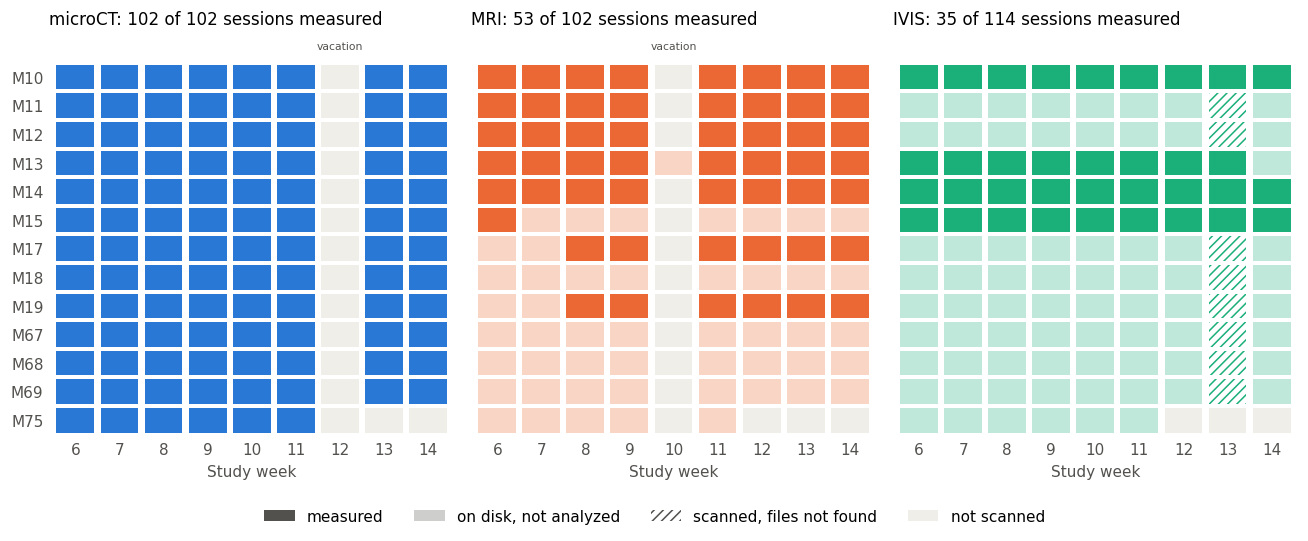

In [4]:
study.plot_coverage()

Each modality tells a different coverage story. **microCT** is complete except the vacation week and
mouse 75, which left after week 11. **MRI** scanned every mouse but was analyzed only in the 8 with
tumor: the rest is on disk, unanalyzed. **IVIS** imaged every cage but was analyzed in 4 mice, and its
week-13 images were never found.

---
# A · What each modality sees

## A1 · Resolution and units

Each modality turns a tumor into a different kind of number, at a different resolution. Every
imaging session in the graph carries the parameters its instrument recorded: the SkyScan
reconstruction log for microCT, the ParaVision `method` file for MRI, and Living Image's
`ClickInfo` for IVIS.

In [5]:
study.resolution()

one MRI voxel = 243 microCT voxels


,measures,voxel / pixel,voxel volume (µm³),result
microCT,air left in the lung (% of lung volume),"36.9 µm, isotropic","50,245","aerated lung, %"
MRI,tumor region drawn on the images,156 × 156 µm × 0.5 mm slices,"12,210,000",tumor voxels (→ mm³)
IVIS,light from luciferase-expressing cells,"2D image, 22.8 cm field of view; blurred by scattering",—,"total flux, photons/s"


### Did the protocol stay the same?

The same parameters, week by week, straight from each session's instrument record:

In [6]:
study.protocol_by_week()

,microCT exposure (ms),microCT recon slices,MRI TR (ms),MRI slices,IVIS exposures (s)
week,,,,,
6,127,493–589,4379.1,46,60
7,127,508–656,4379.1,46,60
8,139,516–695,4379.1,46,60
9,139,608–720,4379.1,46,60
10,139,548–697,4379.1,46,60
11,139,569–646,4379.1,46,60
12,not scanned,not scanned,"4000, 4379.1","40, 46","20, 25, 60"
13,139,602–705,4379.1,46,copy of week 12
14,139,667,4379.1,46,"0.75, 1, 3, 30, 50, 60"


In [7]:
study.protocol_changes()

,id,modality,text
8,OBS-IVIS-EXPOSURE,IVIS,"IVIS used 60 s exposures through week 11, then shorter ones (20-25 s in week 12, 0.75-..."
9,OBS-MCT-EXPOSURE,microCT,microCT exposure changed from 127 ms (weeks 6-7) to 139 ms (week 8 onward); voltage (1...
10,OBS-MCT-W14-RECON,microCT,"Every week-14 reconstruction has exactly 667 slices (SkyScan logs), unlike every earli..."
11,OBS-MRI-W12-SLICES,MRI,"In week 12 most T2 axial series used 40 slices (20 mm coverage) and TR 4000 ms, instea..."


Four changes surfaced from the instrument files alone, none of them written down anywhere else:
microCT exposure went up at week 8 and week 14 used a fixed reconstruction range; MRI covered 20 mm
instead of 23 mm in week 12; IVIS switched to short exposures once tumors got bright. The MRI change
matters for analysis: a large tumor could extend past the covered region that week.

The MRI results are reported as "pixel counts". Are they areas on one slice, or volumes summed over
slices? The data answers it: one 256 × 256 slice has 65,536 pixels.

In [8]:
study.mri_units()

largest MRI count: 65,774 pixels (M13, week 14); one slice holds 65,536
so the counts are voxels summed over slices: 2.1 to 803 mm³ of tumor


microCT measures tumor *indirectly*: tumor displaces air, so what the analysis reports is the aerated
fraction of the lung. Its 37 µm voxels are fine enough to see small nodules, but the reported number
only moves once enough lung is filled. MRI measures the tumor *directly* at coarser resolution.
IVIS measures *living tumor cells* by their light, not tumor size.

## A2 · Tumor growth, as each modality saw it

For comparison, microCT is shown as **lung lost to tumor**: each mouse's own baseline (mean of weeks
6–8) minus that week's aerated %.

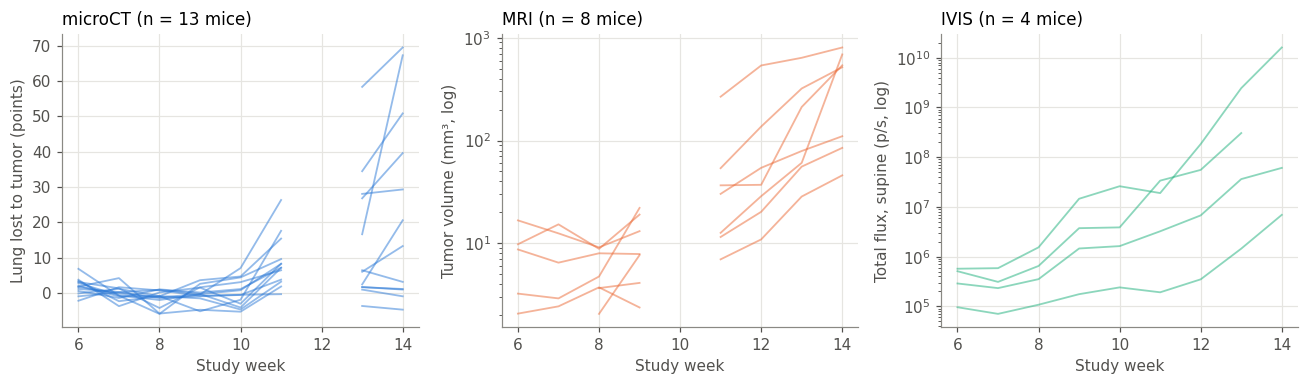

In [9]:
study.plot_growth()

Until about week 10 little changes. From week 11 the mice with tumor pull away on every modality,
while several mice on microCT stay flat for the whole study. The MRI values before week 10 (about
2–20 mm³) are not tumor: they are the floor of the segmentation, what an ROI picks up when there is
nothing to find. The gaps are the vacation weeks (MRI week 10, microCT week 12).

## A3 · When does each modality see a tumor?

**Noise:** how much a measure jumps from week to week in the same mouse before there is any tumor
(weeks 6–9). **Signal:** how far mice with tumor have moved from their own baseline. A modality sees
the tumor once the signal clears the noise. A mouse counts as having **visible tumor** if it lost
more than 10 points of aerated lung by its last scan.

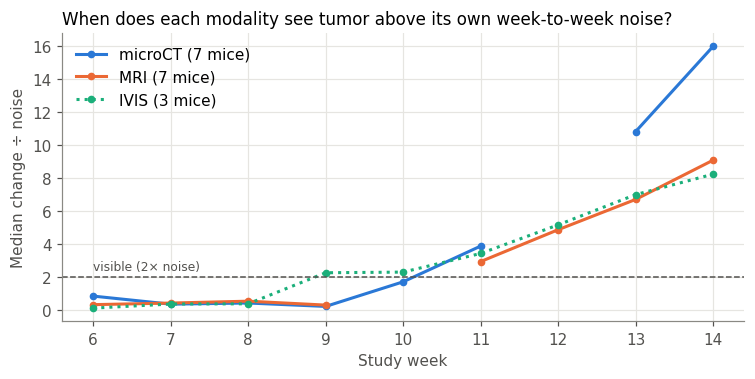

mice with visible tumor: 10, 11, 12, 13, 14, 17, 19
week-to-week noise, weeks 6-9: {'microCT': '2.48 points of lung', 'MRI': '0.42 log mm³', 'IVIS': '0.93 log flux'}
first week above 2× noise: {'microCT': 11, 'MRI': 11, 'IVIS': 9} (dotted = fewer than 5 mice: indicative only)


In [10]:
study.plot_visibility()

microCT and MRI both see tumor from about **week 11**, with two caveats. MRI skipped week 10 (only
one mouse was scanned, and not analyzed), so MRI may have seen tumor a week earlier; microCT at week
10 sits just under the line. IVIS crosses at week 9, but from only 3 mice with tumor, so treat that as a
hint rather than a finding.

## A4 · Do the modalities agree?

Within a single week, do the mice with the most lung lost on microCT also have the most tumor on MRI?

In [11]:
study.agreement()

week,6,7,8,9,10,11,12,13,14
mice,6,5,7,7,0,7,0,7,7
Spearman ρ,0.43,-0.1,-0.07,-0.32,NaN,0.86,NaN,0.93,0.96


Before week 11 there is not enough tumor for the two to agree. From week 11 they rank the mice almost
identically (ρ 0.86 to 0.96). They measure the same tumors in different ways, which is the
result a protocol-development study hopes for.

## A5 · Time and cost per scan

The facility bills imaging by the hour. Time per session depends on how many mice go through the
instrument at once: microCT and MRI image one mouse at a time; IVIS images a cage (up to 5) per
acquisition. These times come from the instruments' own timestamps:

In [12]:
study.cost_per_scan(n_mice=10)

,rate ($/h),"session, 10 mice (h)","cost per mouse-scan, 10 mice ($)",time source
microCT,137.81,0.93,12.86,median gap between consecutive scan starts (SkyScan logs); setup estimated
MRI,275.63,2.23,61.56,"median scanner minutes per mouse (scan logs, all series); setup estimated"
IVIS,144.38,0.49,7.03,"median weekly session length (ClickInfo times) less 15 min luciferin uptake, over 3 ca..."


Checking the time model against how long each weekly session actually took, from the session times in the graph:

In [13]:
study.session_times()

blank: not scanned that week; IVIS week 11 ran over two days (Feb 29 – Mar 1), and IVIS week 13's folder holds week 12's images


actual (min)            model (min)          
          microCT  MRI  IVIS     microCT  MRI IVIS
week                                              
6              63  203    36          70  170   36
7              67  173    32          70  170   36
8              56  241    39          70  170   36
9              61  192    36          70  170   36
10             58   48    28          70   27   36
11             72  166  <NA>          70  170   36
12           <NA>  186    41        <NA>  158   36
13             47  154  <NA>          65  158   36
14             57  151    49          65  158   36

The model tracks the real sessions well. The exceptions have explanations in the data: MRI week 8
ran over an hour long, week 10's MRI was a single mouse with extra series, and IVIS week 11 ran over
two days (week 13's images are the misfiled ones). For reference, what this study's imaging cost:

In [14]:
study.imaging_cost_so_far()

,sessions,hours,cost ($)
microCT,8,9.2,1268
MRI,9,22.5,6202
IVIS,9,5.4,780


## A6 · Storage and software per scan

What this study occupies today, measured from the files on Dropbox and the facility share (atwai):

In [15]:
study.storage()

This study on disk today: 350 GB, of which copies: 154 GB


,location,role,items,GB
0,Dropbox,copy,180,42.21
1,Dropbox,derived,163,1.66
2,Dropbox,document,10,0.12
3,Dropbox,raw,125,109.86
4,Dropbox,result,7,0.00
5,atwai,copy,204,111.75
6,atwai,derived,115,21.74
7,atwai,raw,111,62.88


The same total by modality. `CFT` is cryofluorescence tomography, an endpoint imaging method that is not one of the three modalities compared here:

In [16]:
study.storage_by_modality()

location,Dropbox,atwai,total
modality,,,
CFT,106.4,0.0,106.4
IVIS,0.3,0.0,0.3
MRI,3.0,7.0,10.0
"documents, results",0.1,0.0,0.1
microCT,44.2,189.4,233.5
total,153.9,196.4,350.2


Per mouse-scan, from the size of the data each session is stored in:

In [17]:
study.storage_per_scan()

,MB per mouse-scan
modality,
microCT,547.9
MRI,72.6
IVIS,2.1


In [18]:
study.software()

,modality,step,software,license
0,microCT,acquisition,SkyScan control software (Bruker),with instrument
1,microCT,reconstruction,NRecon (Bruker),with instrument
2,microCT,analysis,aerated-lung segmentation (tool to confirm with analyst),check
3,MRI,acquisition,ParaVision (Bruker),with instrument
4,MRI,analysis,Dragonfly (tumor ROIs),commercial; check license
5,MRI,analysis,Fiji/ImageJ (MRILungTumor.ijm macro),open source
6,IVIS,acquisition + analysis,Living Image,with instrument
7,all,metadata + this notebook,"Neo4j, Python (pandas, scipy, matplotlib)",open source


microCT dominates storage at about half a gigabyte per mouse per scan. MRI is about 75 MB, mostly the
scanner's raw ParaVision data (the DICOM export is 6 MB); IVIS is a few megabytes. Across the study,
about 150 GB are copies: the microCT reconstructions sit in up to four places. The cryofluorescence
(CFT) endpoint volume on Dropbox is the single largest item, about 106 GB in one folder that no
imaging session in the graph points to.

---
# B · Designing a tumor-reduction study

Suppose the next study tests a therapy meant to shrink or slow these tumors. Part A gives everything
needed to design it:

1. **Inject, then enroll by imaging.** Screen at weeks 10–11, when tumor first clears the noise on
   microCT and MRI. Enroll only mice with visible tumor, and randomize with stratification by tumor
   size so both arms start alike. (Part C estimates how many mice to inject to enroll enough.)
2. **Treat and image weekly** from enrollment. In this model the window is about **3–4 weeks**:
   tumors just visible at week 11 reached the largest burden in the study by week 14 (mouse 13 had
   about 11% of its lung still aerated). That also brings the study close to humane endpoints.
3. **Choose the endpoint before the first scan:**
   * change from each mouse's own enrollment scan (fold change or growth rate), with enrollment size
     as a covariate: the most efficient use of imaging
   * tumor size at a fixed week, treated vs. control (tumor growth inhibition)
   * regression: smaller than at enrollment
   * time to progression, or survival if the study continues past imaging

## B1 · How many mice?

An **arm** is one group of the study: here a treated arm and a control (vehicle) arm. "Mice per arm"
is the size of each group, so a two-arm study enrolls twice that many.

The number of mice depends on the effect you need to detect and on how much the measure varies
between mice with tumor. Two designs, from this study's variability:

For a measure on a log scale with between-mouse standard deviation SD, the mice per arm to detect a
fractional reduction *effect* (5% significance, 80% power) is

  **n = 2 × ((1.96 + 0.84) × SD / ln(1 − effect))²**

In [19]:
study.mice_per_arm(effects=[0.2, 0.3, 0.4, 0.5, 0.7, 0.8])

mice  SD (log)  20%  30% 40% 50% 70% 80%
modality design                                                     
microCT  size at week 14       7      0.62  122   48  24  13   5   3
MRI      size at week 14       7      1.17  432  169  83  45  15   9
         growth week 11→14     7      0.97  296  116  57  31  11   6
IVIS     size at week 14       2       NaN    —    —   —   —   —   —
         growth week 11→14     2       NaN    —    —   —   —   —   —

For comparison, most published mouse imaging efficacy studies use **about 5–10 mice per arm**. This
model gets there for the large effects that a successful therapy usually shows (70–80% less tumor):
about 2–5 per arm on microCT, 6–15 on MRI. Detecting a subtle 40% effect takes several times more,
which is a reason to improve the model before running that study, not to use hundreds of mice.
IVIS ("—") was measured in too few mice with tumor to estimate.

There is no microCT growth row on purpose. microCT's number is lung *lost*, not a tumor volume: at
enrollment it is close to zero (sometimes negative), so a fold change from it is unstable, and it
cannot grow past the size of the lung. Growth on microCT is handled as a rate in points per week (B2).

One more caution: a spread estimated from 7 mice is itself uncertain.

In [20]:
study.sd_uncertainty(effect=0.7, k=7)

95% range on a variance from 7 mice: x0.42 to x4.85; mouse numbers scale the same way
  microCT, 70% effect: 5 per arm (plausibly 3 to 25)
  MRI, 70% effect: 15 per arm (plausibly 7 to 73)


## B2 · How many scans?

For a growth-rate endpoint, every extra weekly scan sharpens each mouse's estimate, up to a point.
Mice needed to detect **50% slower growth**, by number of weekly scans after enrollment:

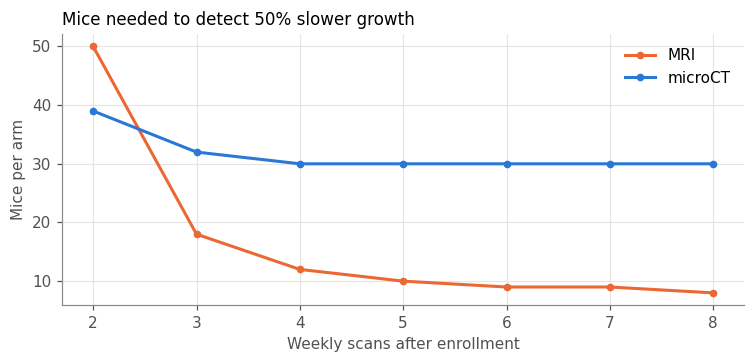

growth per week (mean ± SD between mice, n): {'microCT': '8.96 ± 6.19 points of lung, n=7', 'MRI': '0.74 ± 0.32 log mm³, n=7', 'IVIS': '1.48 ± 0.70 log flux, n=3'}


modality,MRI,microCT
weekly scans,,
2,50,39
3,18,32
4,12,30
5,10,30
6,9,30
7,9,30
8,8,30


In [21]:
growth_multiplier = 0.5
study.scans_needed(slower=growth_multiplier)

**The endpoint picks the modality.** For tumor size at a fixed week (B1), microCT needs the fewest
mice. For growth rate, MRI does: on a log scale its tumors grow at a similar rate in every mouse
(0.74 ± 0.32 per week), so four scans pin each mouse's rate down and about 12 mice per arm detect a
halving. microCT's rate in points of lung varies far more between mice (9 ± 6 points per week), and
that spread is real biology plus a measure that saturates, so extra scans don't help: it stays near 30
per arm.

Either way the gains stop at about **four weekly scans**, which is also the window this model allows
(weeks 11–14). IVIS is left out: too few mice.

## B3 · What would the study cost?

Two arms of the headline design (70% effect, size at week 14), a screening scan at week 10 for every
injected mouse, then weekly scans of the enrolled mice from week 11 (set the number of scans here;
4 covers weeks 11–14, the window this model allows):

In [22]:
SCANS_AFTER_ENROLLMENT = 10
study.design_cost(effect=0.7, scans_after_enrollment=SCANS_AFTER_ENROLLMENT, copies=2)

,mice per arm,mice enrolled,imaging after enrollment ($),"storage, 2 copies (GB)"
microCT,5,10,1286,107.0
MRI,15,30,17089,42.5


In [23]:
study.xray_dose(scans=1 + SCANS_AFTER_ENROLLMENT)     # screening scan + weekly scans

microCT x-ray dose: about 434 mGy per scan (scanner estimate), 4.8 Gy over 11 scans per mouse (this study: 3.5 Gy over 8)


Radiation at that level can slow tumor growth on its own, so a microCT-based design should image
both arms identically and keep the number of scans to what the endpoint needs.

Enrollment needs a screening scan of every injected mouse, and how many to inject depends on how
reliably the model produces tumors. That is part C.

---
# C · What the data says about the tumor model

The study was designed to compare measurements, not to test the USGI injection. But microCT was
analyzed in every mouse, so the data can answer a question nobody asked: **how often did the
injection produce a measurable tumor, and when did it appear?**

Mice 67, 68, 69 and 75 were controls (not injected), so they are left out of the take rate. Edit the
list below and rerun to see how the answer changes.

In [24]:
study.tumor_outcomes()

,lung lost by last scan (points),last scan (week),tumor visible from week,tumor,MRI analyzed,IVIS analyzed
subject,,,,,,
M13,69.5,14,10.0,True,True,True
M17,67.3,14,11.0,True,True,False
M10,50.8,14,11.0,True,True,True
M12,39.6,14,11.0,True,True,False
M19,29.3,14,11.0,True,True,False
M14,20.5,14,14.0,True,True,True
M11,13.2,14,11.0,True,True,False
M75,3.7,11,NaN,False,False,False
M15,3.1,14,NaN,False,True,True


In [25]:
NOT_INJECTED = ["M67", "M68", "M69", "M75"]     # controls: not injected
study.take_rate(not_injected=NOT_INJECTED)

injected mice: 9; followed to week 14: 9; left early: none
measurable tumor by week 14: 7 of 9 = 78%
week each tumor became visible: [10, 11, 11, 11, 11, 11, 14] (median week 11)


The tumors that took split into two clear groups: lung lost by week 14 is 13 to 70 points in seven
mice and essentially zero in the rest, so the take rate barely depends on the threshold. Onset is
consistent: one tumor was visible at week 10, five at week 11, and one (mouse 14) only at week 14. A
therapy study enrolling at week 11 would catch six of the seven and miss the slow one.

### Mice to inject

Put it together: to enroll the mice part B needs, inject enough to cover the take rate and early
losses, then add the screening scan:

In [26]:
study.mice_to_inject(effect=0.7, not_injected=NOT_INJECTED, scans_after_enrollment=SCANS_AFTER_ENROLLMENT)

,mice enrolled,mice to inject,"screening, microCT ($)",imaging after enrollment ($),total imaging ($),storage (GB)
microCT,10,13,160,1286,1446,107.0
MRI,30,39,435,17089,17524,42.5


The tumor model, not the imaging, sets how many animals the study uses: with 7 of 9 injected mice
growing a measurable tumor, about 1.3 mice must be injected for every mouse enrolled. Improving the injection (dose, technique, confirming delivery) is the cheapest
way to cut animal numbers.

---
## The plan, side by side

In [27]:
study.plan(effect=0.7, not_injected=NOT_INJECTED, scans_after_enrollment=SCANS_AFTER_ENROLLMENT)

,resolution,first visible week,"cost per mouse-scan, 10 mice ($)",MB per mouse-scan,"mice per arm, 70% effect",mice to inject,total imaging ($)
microCT,"36.9 µm, isotropic",11,12.86,547.9,5,13,1446
MRI,156 × 156 µm × 0.5 mm slices,11 (week 10 skipped),61.56,72.6,15,39,17524
IVIS,"2D image, 22.8 cm field of view; blurred by scattering",9 (3 mice: indicative),7.03,2.1,too few mice,too few mice,too few mice


**Takeaways for the next study**

* **Enroll by imaging at weeks 10–11** and image weekly for about four weeks; earlier scans mostly
  record baseline in this model.
* **microCT** is the cheapest per scan, needs the fewest mice and generates the most data. Its
  measure is indirect (air displaced), so pair it with MRI on a subset if tumor volume matters.
* **MRI** measures the tumor directly but costs the most per scan and varies more between mice.
* **IVIS** needs to be analyzed in every animal, in one agreed view, before it can carry an endpoint.
* **The tumor model sets the animal count:** about 1.3 injections per enrolled mouse (78% take).
  Improving take is the most effective reduction.
* **Plan the data too:** one canonical copy, one long results table, a reason for every gap.

---
# D · Curating the data, hands-on

The coverage grid at the top showed what exists. Two more angles show what it can support. First,
how many mice have analyzed data on more than one modality in the same week? That is what any
comparison between modalities can use:

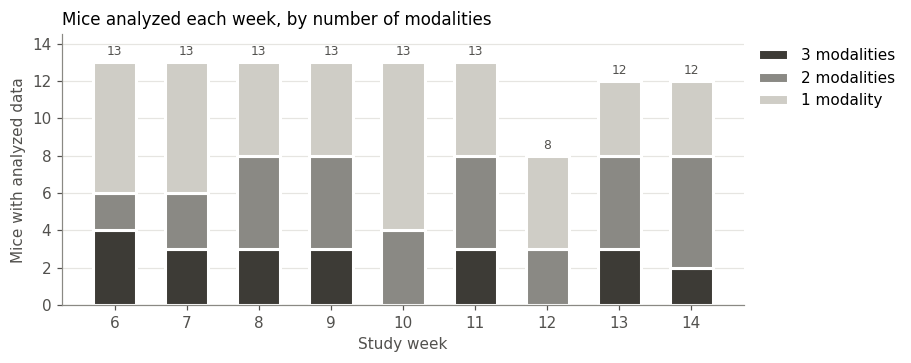

week,6,7,8,9,10,11,12,13,14
3 modalities,4,3,3,3,0,3,0,3,2
2 modalities,2,3,5,5,4,5,3,5,6
1 modalities,7,7,5,5,9,5,5,4,4


In [28]:
study.coverage_by_week()

And per mouse: how long a series does each mouse have on each modality? Mice marked ★ had visible
tumor on microCT.

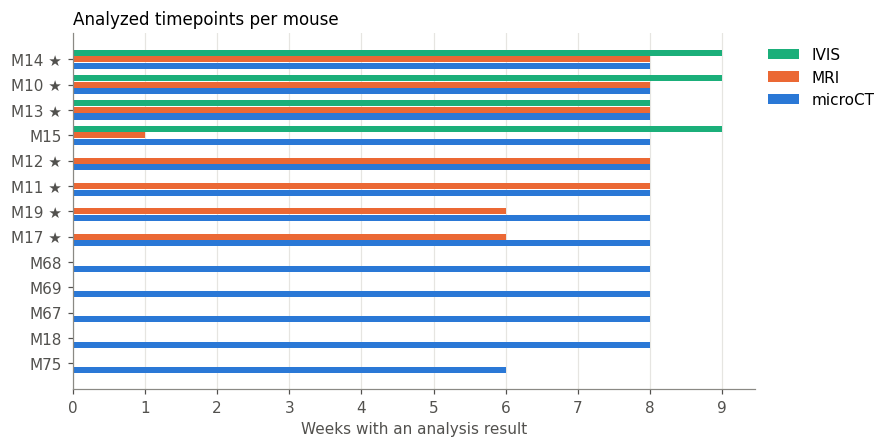

In [29]:
study.coverage_by_mouse()

Only four mice have all three modalities analyzed over time, and they were chosen to span high and low
tumor burden. The unanalyzed MRI and IVIS sessions are the cheapest new data this study can offer:
they are already on disk.

### What's on disk now

Putting this study into the graph surfaced the usual problems:

* **Copies that disagree:** microCT reconstructions in three identical places on the facility
  share, plus a Dropbox copy that stops at week 11.
* **A misfiled folder:** the Dropbox "week 13" IVIS folder is a copy of week 12, though the analysis
  sheet has real week-13 values.
* **Inconsistent names:** `12T2axial.dcm`, `15T2.dcm`, `17-T2W.dcm`, `1013_T2_axial.dcm` (mouse 13);
  microCT week 7 named by cage and ear punch on Dropbox; MRI sessions named `multimodelLung`,
  `multiModelLung` and `multimodalLung` on the scanner.
* **Results versioned by file name:** `... measurements 2 (Milton's changes 2024-05-28).xlsx`.
* **Results as presentation spreadsheets:** the IVIS sheet holds four views, a duplicate block and
  a %-change table in one grid, which had to be parsed by hand.

### From the graph to the files

The graph records where every session's data lives: which folder or file holds it, what was derived
from it, and how many copies exist. For one mouse in one week:

In [30]:
files = g.run("session_files")
files[(files.subject == "M13") & (files.week == 13)]

,subject,modality,week,link,node,role,location,path,bytes,copies
234,M13,MRI,13,HAS_DERIVED,File,derived,Dropbox,MultiModal/LungTumor/MRI/03-11-2024/13-week13.tif,12092652.0,0
235,M13,MRI,13,HAS_DERIVED,File,derived,Dropbox,MultiModal/LungTumor/MRI/DragonflyROIs/roi-13-week13.ORSObject,106895.0,0
236,M13,MRI,13,STORED_IN,Folder,raw,atwai,/data0/core/atwai/huangw/2024/20240311_142100_AIPT_20240311multimodalLung_1_99,765747631.0,0
237,M13,MRI,13,STORED_IN,File,raw,Dropbox,MultiModal/LungTumor/MRI/03-11-2024/1013.dcm,6041174.0,1
238,M13,microCT,13,HAS_DERIVED,Folder,derived,atwai,/data0/core/atwai/archive/microct/longitudinal mouse lung tumors/wk13_13_Rec-Nifti,105510591.0,0
239,M13,microCT,13,STORED_IN,Folder,raw,atwai,/data0/core/atwai/Anderson_Scott/Multimodal/MultiModal Lung tumor test/raw data/wk13_1...,606085884.0,2


Mouse 13's week 13 lives in several places: the MRI scanner's study folder and an exported DICOM
(with an XNAT copy), and a microCT reconstruction with two more copies and a NIfTI conversion beside
it. Section A6 sums the same idea over the whole study.

### Which machines hold each session?

Every folder and file in the graph carries the machine it sits on, and each top folder links to a
`Host` node: the Dropbox folder (synced to ki-ed3g), the facility file server bmc-lab6 that serves
atwai, the microCT instrument PC that wrote the scans, and the GitHub repository with the results.

In [31]:
g.show("hosts")
g.run("hosts")[["host", "role", "note", "synced_to"]]

// The machines that hold or produced this study's data
MATCH (h:Host)
OPTIONAL MATCH (h)<-[:ON_HOST]-(root)
OPTIONAL MATCH (h)-[:SYNCED_TO]->(m:Host)
RETURN h.name AS host, h.role AS role, h.note AS note,
       collect(DISTINCT root.path) AS top_folders, collect(DISTINCT m.name) AS synced_to
ORDER BY role, host


,host,role,note,synced_to
0,Dropbox (MIT),cloud storage,synced folder AIPT/Imaging/MultiModal/LungTumor,[ki-ed3g]
1,GitHub (science_data_kit),code repository,"analysis results as delivered, versioned with this demo",[]
2,bmc-lab6,file server,serves the facility share atwai at /data0/core/atwai,[]
3,MICROCT,instrument PC,SkyScan 1276 acquisition and reconstruction PC; writes to D:\Results,[]
4,ki-ed3g,workstation,Dropbox synced at /mnt/data/cloud/Dropbox (MIT); runs the atwai scan index,[]


Following each session to the data it is stored in, and to every copy of that data, gives the set of
machines holding it. Each cell below shows where that modality's sessions for that week can be found:

In [32]:
g.show("session_hosts")
study.where_sessions_live()

// Which machines hold each session's data: the canonical copy and every copy of it
MATCH (se:ImagingSession)-[:STORED_IN]->(f)
OPTIONAL MATCH (c)-[:COPY_OF]->(f)
WITH se, f, collect(c) AS cs
UNWIND [f] + cs AS item
WITH se, collect(DISTINCT item.host) AS hosts, count(DISTINCT item) AS stored_items
MATCH (se)-[:OF_SUBJECT]->(su:Subject)
RETURN su.id AS subject, se.modality AS modality, se.study_week AS week, hosts, stored_items
ORDER BY modality, week, subject


modality,microCT,MRI,IVIS
week,,,
6,bmc-lab6 + dropbox,bmc-lab6 + dropbox,dropbox
7,bmc-lab6,bmc-lab6 + dropbox,dropbox
8,bmc-lab6 + dropbox,bmc-lab6 + dropbox,dropbox
9,bmc-lab6 + dropbox,bmc-lab6 + dropbox,dropbox
10,bmc-lab6 + dropbox,bmc-lab6 + dropbox,dropbox
11,"bmc-lab6 + dropbox (12 mice), bmc-lab6 (1 mouse)",bmc-lab6 + dropbox,dropbox
12,no session,bmc-lab6 + dropbox,dropbox
13,bmc-lab6,bmc-lab6 + dropbox,files not found
14,bmc-lab6,bmc-lab6 + dropbox,dropbox


In [33]:
study.single_host_sessions()

Sessions held on one machine only:


,modality,hosts,sessions,weeks,copies_on_that_machine
0,IVIS,dropbox,102,"[6, 7, 8, 9, 10, 11, 12, 14]",1.0
1,microCT,bmc-lab6,38,"[7, 11, 13, 14]",3.0


What this shows:

* **IVIS exists only on Dropbox.** No copy on the facility server was found, so the Dropbox folder
  is the only place the optical data lives. The week-13 images were not found anywhere: the week-13
  folder is a copy of week 12, though the results have week-13 values.
* **MRI is on both machines**, but they are not the same data: the DICOM exports are on Dropbox and
  the ParaVision raw study folders are on bmc-lab6.
* **microCT weeks 7, 13 and 14 are on bmc-lab6 only** (plus mouse 18 in week 11). Those sessions have
  several copies, but all on the same server under different users' folders, so they are duplicates,
  not a backup. Week 7 does have copies on Dropbox, but named by cage rather than mouse, so they can't be
  matched to a session.

Counting copies says a session is safe; asking *which machines* hold them says whether it is.

### Ask an assistant to curate it

Everything above can be condensed into a short **coverage report**: a text grid of what exists, the
notes and gaps, examples of how files are named today, and where they are stored. Paired with a
curation prompt, it can be given to any AI assistant (Claude, ChatGPT, a local model).

The prompt asks for a short, standard answer rather than an essay: the gaps and risks, the
**standard data objects** every study should keep (README, subjects, sessions, a long measurements
table, a data dictionary, a notes log, a file manifest), a **naming and folder convention** with
before → after examples from this study's own files, a one-line-per-element draft of an **NIH Data
Management and Sharing plan**, and the top five actions. Facts must come from the report; the
conventions follow NIH DMS policy, FAIR principles and library guidance on file naming.

In [34]:
%%time
report = study.coverage_report()
print(report)

STUDY: Multimodal monitoring of mouse lung tumors (protocol development)
Design: 13 mice; modalities microCT, MRI, IVIS; weekly, study weeks 6-14 (2024-01-22 to 2024-03-19).

COVERAGE (one row per mouse, one column per study week)
  M = measured   o = on disk, not analyzed   x = scanned, files not found   . = not scanned

microCT / week  6  7  8  9 10 11 12 13 14
M10             M  M  M  M  M  M  .  M  M
M11             M  M  M  M  M  M  .  M  M
M12             M  M  M  M  M  M  .  M  M
M13             M  M  M  M  M  M  .  M  M
M14             M  M  M  M  M  M  .  M  M
M15             M  M  M  M  M  M  .  M  M
M17             M  M  M  M  M  M  .  M  M
M18             M  M  M  M  M  M  .  M  M
M19             M  M  M  M  M  M  .  M  M
M67             M  M  M  M  M  M  .  M  M
M68             M  M  M  M  M  M  .  M  M
M69             M  M  M  M  M  M  .  M  M
M75             M  M  M  M  M  M  .  .  .
  measured 102 of 102 sessions; 0 on disk not analyzed; 0 files not found

MRI / week   

In [35]:
%%time
prompt = curation_prompt(report)

10,205 characters -> export/curation_prompt.md: paste it into an AI assistant
CPU times: user 833 μs, sys: 59 μs, total: 892 μs
Wall time: 1.12 ms


### Send it to MIT's Parley API

MIT's [Parley](https://parley.mit.edu/) gateway gives everyone at MIT access to models from OpenAI,
Anthropic (Claude, through AWS Bedrock) and Google through one OpenAI-compatible API, billed to their
own account. To run the prompt yourself:

1. **Sign in** to the Parley Admin Portal with your MIT credentials. The first sign-in creates a
   personal account with free credit; students get \$10, faculty and staff \$30. This prompt costs a
   few cents per run.
2. **Copy your key** from *My Keys*. It looks like `sk-parley-v1-...`.
3. **Run the next cell** and paste the key when asked. It is held in memory only and never saved in
   the notebook. To skip the prompt, put `PARLEY_API_KEY=sk-parley-v1-...` in a `parley.env` file
   next to the notebook (git-ignored) or set it as an environment variable.

Two rules: **treat the key like a password** (never paste it into a cell, a slide or a chat), and
send Parley only **low- or medium-risk data**, per MIT policy. This report is fine: mouse IDs, weeks
and file locations, no people's data.

In [36]:
%%time
from IPython.display import Markdown
answer = ask_parley(prompt)            # or ask_parley(prompt, model="...") to pick a model
if answer:
    display(Markdown(answer))

No Parley key: skipped. The prompt is in export/curation_prompt.md for any assistant.
CPU times: user 147 μs, sys: 11 μs, total: 158 μs
Wall time: 157 μs


The proposed notes (section 7 of the answer) come back as JSON, so they can be checked as a table
before anything goes into the graph:

In [37]:
if answer:
    notes = proposed_notes(answer)
    print(f"{len(notes)} new notes proposed; the graph already has {len(study.observations)}")
    display(notes)
else:
    print("No answer yet: run the Parley cell above with your key.")

No answer yet: run the Parley cell above with your key.


**Try it on your own data.** The prompt doesn't depend on this study. Make the same kind of report for
your dataset, even by hand (a row per subject, a column per timepoint, a letter for what exists),
add any notes you already have, and paste both. What comes back is a starting point: check every
claim against the files before acting on it. The notes in section 7 are written so they can go
straight back into the graph as new Observation nodes.

---
# Appendix · Under the hood

## The whole dataset in one call

This is the query behind the summary at the top. It walks the graph once: every imaging session,
its mouse, its modality and any measurements, then the notes attached to each modality.

In [38]:
g.show("dataset_summary")
g.run("dataset_summary")

// The whole dataset in one call: per modality, what was imaged, what was
// measured, over which weeks, and how many curator notes are attached.
MATCH (st:Study)-[:HAS_DATA]->(se:ImagingSession)
      -[:IMAGED_WITH]->(mo:Modality)
MATCH (se)-[:OF_SUBJECT]->(su:Subject)
OPTIONAL MATCH (se)-[:HAS_MEASUREMENT]->(m:Measurement)
WITH mo, count(DISTINCT se) AS sessions, count(DISTINCT su) AS mice_imaged,
     count(DISTINCT CASE WHEN m IS NOT NULL THEN su END) AS mice_measured,
     count(m) AS measurements, collect(DISTINCT m.kind) AS kinds,
     collect(DISTINCT se.study_week) AS weeks,
     min(se.acq_date) AS first_scan, max(se.acq_date) AS last_scan
OPTIONAL MATCH (o:Observation)-[:ABOUT]->(mo)
RETURN mo.name AS modality, mice_imaged, mice_measured, sessions, measurements,
       size(weeks) AS weeks_imaged, first_scan, last_scan, kinds, count(o) AS notes
ORDER BY modality


,modality,mice_imaged,mice_measured,sessions,measurements,weeks_imaged,first_scan,last_scan,kinds,notes
0,IVIS,13,4,114,83,9,2024-01-22,2024-03-19,"[total_flux, total_flux_left, total_flux_prone, total_flux_right]",4
1,MRI,13,8,102,53,9,2024-01-22,2024-03-18,[tumor_pixel_count],3
2,microCT,13,13,102,102,8,2024-01-22,2024-03-18,[aerated_lung_pct],6


Because the reasons for gaps live in the graph as notes, the summary can say *why* data is missing:

In [39]:
g.run("gaps")

,modality,last_before,first_after,mice_affected,explained_by,reason
0,MRI,9,11,12,OBS-GAP-MRI-W10,MRI specialist on vacation that week
1,microCT,11,13,12,OBS-GAP-MCT-W12,microCT specialist on vacation that week


## A layout built from the key variables

The key variables are **study, modality, mouse, week**. Make them the folder path and the file name,
keep raw data read-only, and keep every result in one long table:

```
LungTumor_2024/
├── README.md                    # design, people, protocol, dates
├── study.json                   # machine-readable version of the README
├── subjects.csv                 # mouse, cage, ear punch, group, sex, age
├── observations.json            # gaps, dropouts, QC notes, with reasons
├── raw/                         # read-only, one canonical copy (+ one backup)
│   └── microCT/wk06/M010/ ...   # <modality>/wk<NN>/M<NNN>/ instrument files as written
├── derived/                     # reconstructions, ROIs, masks; each with the software version
│   └── MRI/dragonfly_rois/wk11/M013/ ...
├── results/
│   └── measurements.csv         # mouse, week, modality, kind, value, unit, method, version
└── manifest.csv                 # every file: path, size, checksum, session id
```

The graph can generate both the target path for every session and the long results table, so the
reorganization is a copy job rather than a manual one:

In [40]:
study.export_layout()

318 sessions -> export/session_layout.csv; 238 measurements -> export/measurements_long.csv


,session,subject,modality,week,acq_date,target_path
0,LWM-IVIS-M10-W06,M10,IVIS,6,2024-01-22,raw/IVIS/wk06/M010/
1,LWM-IVIS-M10-W07,M10,IVIS,7,2024-01-29,raw/IVIS/wk07/M010/
2,LWM-IVIS-M10-W08,M10,IVIS,8,2024-02-05,raw/IVIS/wk08/M010/
3,LWM-IVIS-M10-W09,M10,IVIS,9,2024-02-13,raw/IVIS/wk09/M010/
4,LWM-IVIS-M10-W10,M10,IVIS,10,2024-02-20,raw/IVIS/wk10/M010/


Principles behind it:

* **One source of truth.** One canonical copy plus a backup; everything else is a link or a query.
* **Raw is read-only.** Derived files record which raw files, software and version produced them.
* **IDs and dates are fixed-width and sortable:** `M013`, `wk06`, `2024-03-12`.
* **Results are long and tidy:** one row per measurement, with its unit and method, never a grid.
* **Versions are a column, not a file name.**
* **Every gap gets a reason, written where the data lives.** That is what made the vacation weeks
  explainable here.

## Ask your own questions

Every table above comes from a named query. `g.show(name)` prints its Cypher and `g.run(name)`
returns the answer as a pandas DataFrame, live or offline. On the live graph, `g.cypher(...)` runs any
Cypher you write, for example every acquisition of mouse 13 in week 13:

In [41]:
if g.live:
    display(g.cypher("""
        MATCH (se:ImagingSession)-[:HAS_ACQUISITION]->(a)-[:ON_INSTRUMENT]->(i:Instrument)
        WHERE se.id IN ['LWM-MRI-M13-W13', 'LWM-MCT-M13-W13']
        RETURN se.modality AS modality, i.name AS instrument, count(a) AS acquisitions
    """))
else:
    print("Custom Cypher needs the live graph. Named questions:", ", ".join(g.queries()))

Custom Cypher needs the live graph. Named questions: acquisitions, coverage, dataset_summary, gaps, hosts, instruments, measurements, modalities, node_counts, observations, relationship_counts, result_files, session_coverage, session_files, session_hosts, sessions, storage_by_location, storage_by_modality, study, subjects
